In [1]:
import os
import datetime

import colorcet as cc
import contextily as cx
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
import pandas as pd
from bokeh.plotting import figure, output_notebook, show
from bokeh.models import HoverTool, Title
from pathlib import Path
import folium
import rioxarray
import netCDF4

from shapely.geometry import box

from blackmarble.extract import bm_extract
from blackmarble.raster import bm_raster

import xarray as xr
import numpy as np

%load_ext autoreload
%autoreload 2

plt.rcParams["figure.figsize"] = (18, 10)
pd.set_option('display.max_rows', 50)

In [7]:
# Import Data

In [3]:
#Shape File
gdf_Sababi = gpd.read_file("SL_SixRegions/SL_SixRegions.shp")

In [84]:
#Sam Data Source
SL_VNP46A4_EY_2012_24 = xr.open_dataset("NTL_Data_A4/V2_SL_VNP46A4_EY_2012_24.nc")
df = SL_VNP46A4_EY_2012_24.where(SL_VNP46A4_EY_2012_24 != 6553.5, np.NaN)

In [85]:
#Phillip Data
tif_df = rioxarray.open_rasterio("NTL_Data_A4/Phillip_Somaliland_Only.tif", masked=True)

In [5]:
yearly_sums = []
for year in range(2012, 2024):
    # Select data for the year and sum all values
    yearly_sum = SL_VNP46A4_EY_2012_24["NearNadir_Composite_Snow_Free"].sel(time=f"{year}-01-01").sum().item()
    yearly_sums.append(yearly_sum)
print("Total Yearly Radiance Somaliland - Sam Data")
for i in range(12):
    print(f"{2012+i}: {np.round(yearly_sums,2)[i]}")

Total Yearly Radiance Somaliland
2012: 1500.4
2013: 1670.8
2014: 1836.3
2015: 1997.3
2016: 2167.3
2017: 2555.8
2018: 3242.9
2019: 3973.9
2020: 5029.0
2021: 6835.1
2022: 8414.8
2023: 9225.1


In [114]:
yearly_sums = []
for year in range(1, 13):
    # Select data for the year and sum all values
    yearly_sum = tif_df.sel(band=year).sum().item()
    yearly_sums.append(yearly_sum)
print("Total Yearly Radiance Somaliland - Phillip Data")
for i in range(12):
    print(f"{2012+i}: {np.round(yearly_sums,2)[i]}")

Total Yearly Radiance Somaliland - Phillip Data
2012: 1533.0
2013: 1703.5
2014: 1866.7
2015: 2033.4
2016: 2205.6
2017: 2601.2
2018: 3338.9
2019: 4088.6
2020: 5200.3
2021: 7123.8
2022: 8823.7
2023: 9760.4


In [115]:
tif_df

<xarray.DataArray (band: 12, y: 843, x: 1535)>
[15528060 values with dtype=float32]
Coordinates:
  * band         (band) int32 1 2 3 4 5 6 7 8 9 10 11 12
  * x            (x) float64 42.69 42.69 42.69 42.7 ... 49.06 49.07 49.07 49.08
  * y            (y) float64 11.51 11.51 11.5 11.5 ... 8.015 8.01 8.006 8.002
    spatial_ref  int32 0
Attributes:
    AREA_OR_POINT:       Area
    STATISTICS_MAXIMUM:  23.299999237061
    STATISTICS_MEAN:     -9999
    STATISTICS_MINIMUM:  0
    STATISTICS_STDDEV:   -9999
    scale_factor:        1.0
    add_offset:          0.0
    long_name:           ('t2012', 't2013', 't2014', 't2015', 't2016', 't2017...

In [116]:
df

<xarray.Dataset>
Dimensions:                        (time: 12, y: 843, x: 1535)
Coordinates:
  * x                              (x) float64 42.69 42.69 42.69 ... 49.07 49.08
  * y                              (y) float64 11.51 11.51 11.5 ... 8.006 8.002
  * time                           (time) datetime64[ns] 2012-01-01 ... 2023-...
Data variables:
    NearNadir_Composite_Snow_Free  (time, y, x) float64 nan nan nan ... nan nan
Attributes: (12/40)
    AlgorithmType:                     b'SCI'
    AlgorithmVersion:                  b'NPP_PR46A3 2.0.0'
    Conventions:                       b'CF-1.6'
    DataResolution:                    b'15 arc second'
    DayNightFlag:                      b'Night'
    HorizontalTileNumber:              b'22'
    ...                                ...
    NorthBoundingCoord:                20.0
    publisher_email:                   b'modis-ops@lists.nasa.gov'
    publisher_name:                    b'LAADS'
    publisher_url:                     b'https://ladsweb.modaps.eosdis.nasa.gov'
    SouthBoundingCoord:                10.0
    WestBoundingCoord:                 40.0

In [ ]:
print(tif_df.dims)
print(df.dims)

print(tif_df.coords)
print(df.coords)

print(tif_df.rio.crs)

('band', 'y', 'x')
Frozen({'time': 12, 'y': 843, 'x': 1535})
Coordinates:
  * band         (band) int32 1 2 3 4 5 6 7 8 9 10 11 12
  * x            (x) float64 42.69 42.69 42.69 42.7 ... 49.06 49.07 49.07 49.08
  * y            (y) float64 11.51 11.51 11.5 11.5 ... 8.015 8.01 8.006 8.002
    spatial_ref  int32 0
Coordinates:
  * x        (x) float64 42.69 42.69 42.69 42.7 42.7 ... 49.06 49.07 49.07 49.08
  * y        (y) float64 11.51 11.51 11.5 11.5 11.49 ... 8.015 8.011 8.006 8.002
  * time     (time) datetime64[ns] 2012-01-01 2013-01-01 ... 2023-01-01
EPSG:4326


In [22]:
df_x = df["x"].values
df_y = df["y"].values

In [25]:
tif_x = tif_df["x"].values
tif_y = tif_df["y"].values

In [31]:
x_check = df_x - tif_x
y_check = df_y - tif_y

In [32]:
sum(x_check)
sum(y_check)

0.10290527343637024

In [35]:
print(df_x[1])
print(tif_x[1])

42.68970540364583
42.68958333333333


In [36]:
band12 = tif_df.sel(band=12)
max_tif_value = band12.max().item()

print("Max value in band 12:", max_tif_value)

Max value in band 12: 198.89999389648438


In [49]:
ds_2023 = SL_VNP46A4_EY_2012_24.sel(time="2023")
max_nc_value = ds_2023["NearNadir_Composite_Snow_Free"].max().item()

print("Max radiance in 2023:", max_nc_value)

Max radiance in 2023: 175.0


In [52]:
# For tif
idx = np.unravel_index(band12.argmax().values, band12.shape)
max_y, max_x = band12.y[idx[0]].values, band12.x[idx[1]].values
print(f"Max location in tif: x={max_x}, y={max_y}")

# For NetCDF
idx_nc = np.unravel_index(ds_2023["NearNadir_Composite_Snow_Free"].argmax().values, ds_2023["NearNadir_Composite_Snow_Free"].shape)
lat = ds_2023["x"][idx_nc[0]].values
lon = ds_2023["y"][idx_nc[1]].values
print(f"Max location in 2023 VIIRS: x={lat}, y={lon}")

Max location in tif: x=44.99375, y=10.435416666666667
Max location in 2023 VIIRS: x=42.68553873697917, y=10.431372070312499


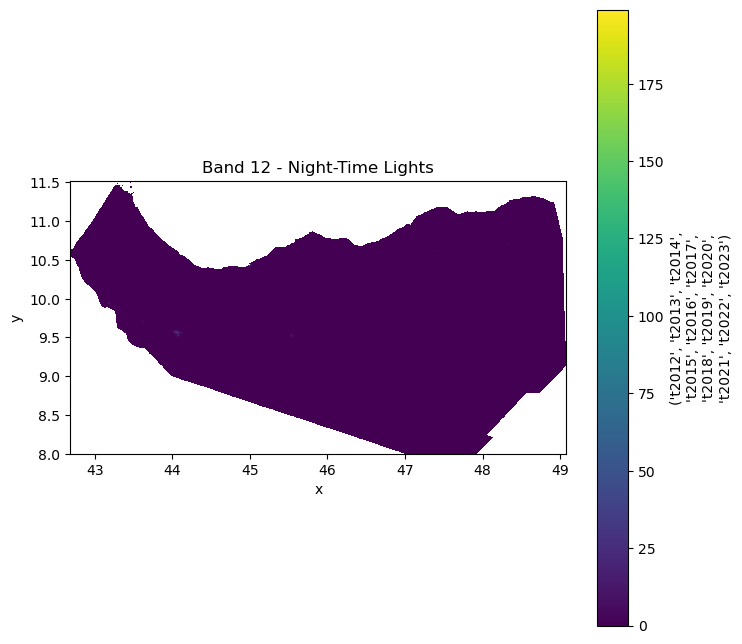

In [54]:
band12 = tif_df.sel(band=12).squeeze()

# Plot with square aspect
plt.figure(figsize=(8, 8))
band12.plot(cmap="viridis")
plt.gca().set_aspect('equal')
plt.title("Band 12 - Night-Time Lights")
plt.show()

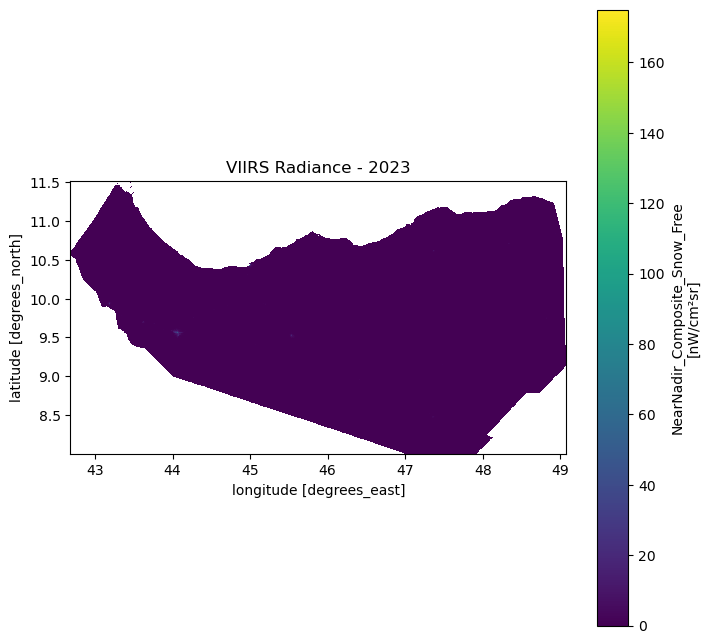

In [57]:
radiance = SL_VNP46A4_EY_2012_24["NearNadir_Composite_Snow_Free"]

# If it's time-based, filter for the specific year
if "time" in radiance.dims:
    radiance = radiance.sel(time="2023")

# Plot with square aspect ratio
plt.figure(figsize=(8, 8))
radiance.plot(cmap="viridis")
plt.gca().set_aspect('equal')
plt.title("VIIRS Radiance - 2023")
plt.show()

In [98]:
df_values = np.nan_to_num(df.sel(time="2023")["NearNadir_Composite_Snow_Free"].values.flatten(), nan=0)

In [99]:
tif_values = np.nan_to_num(tif_df.sel(band=12).values.flatten(), nan=0)

In [101]:
sum(df_values)

9225.10000000003

In [102]:
sum(tif_values)

9760.39999872446

In [103]:
diff_np = tif_values - df_values

In [107]:
sum(diff_np)

535.2999987244559

In [106]:
diff_np[diff_np > 1]

array([  2.29999995,   1.89999998,   2.20000005,   1.10000002,
         1.89999998,  17.70000076,  35.79999924, 198.8999939 ,
       140.80000305,   4.4000001 ,  88.40000153,   2.79999995,
        10.        ,   5.0999999 ,   1.89999998,   1.29999995,
         6.5999999 ,   2.0999999 ])

In [109]:
diff_np[diff_np < -1]

array([], dtype=float64)

ValueError: Dataset.plot cannot be called directly. Use an explicit plot method, e.g. ds.plot.scatter(...)

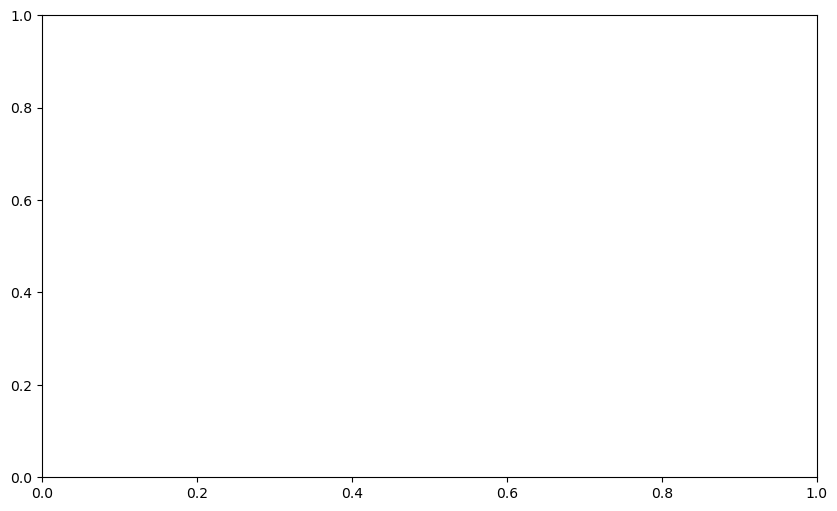

In [74]:
# Set CRS for both dataframes
tif_df = tif_df.rio.write_crs("EPSG:4326", inplace=False)
df = df.rio.write_crs("EPSG:4326", inplace=False)

# Step 2: Reproject df (NetCDF) to match tif_df grid
df_aligned = df.rio.reproject_match(tif_df)

# Step 3: Crop tif_df to common extent if needed
tif_cropped = tif_df.sel(x=df_aligned.x, y=df_aligned.y)

# Step 4: Calculate difference and store in a new dataframe
df_diff = tif_cropped.sel(band=12) - df_aligned.sel(time="2023")

# Step 5: Plot the difference dataframe
plt.figure(figsize=(10, 6))
ax = plt.axes()  # Create axes explicitly

# If df_diff is a DataArray, plot it directly
df_diff.plot(ax=ax)
plt.title("Difference between TIFF and NetCDF data")
    
    # Print summary statistics
print("Summary statistics:")
print("Mean difference:", df_diff.mean().item())
print("Max difference:", df_diff.max().item())
print("Min difference:", df_diff.min().item())

ax.set_aspect('equal')  # Set aspect on the axes object directly
plt.show()

In [76]:
df_diff

<xarray.Dataset>
Dimensions:                        (x: 1535, y: 843, time: 1)
Coordinates:
  * x                              (x) float64 42.69 42.69 42.69 ... 49.07 49.08
  * y                              (y) float64 11.51 11.51 11.5 ... 8.006 8.002
  * time                           (time) datetime64[ns] 2023-01-01
    spatial_ref                    int32 0
    band                           int32 12
Data variables:
    NearNadir_Composite_Snow_Free  (y, x, time) float64 nan nan nan ... nan nan

In [83]:
sum(df_diff["NearNadir_Composite_Snow_Free"].values.flatten())

nan

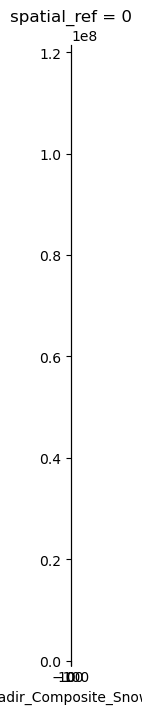

In [71]:
plt.figure(figsize=(8, 8))
df_diff["NearNadir_Composite_Snow_Free"].plot()
plt.gca().set_aspect('equal')